In [1]:
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)
# device = torch.device(
#                     "cuda"
#                     if torch.cuda.is_available()
#                     else "mps" if torch.backends.mps.is_available() else "cpu"
#                 )
# print(f"Using {device}")

# load & preprocess
data = sio.loadmat('../data/mine_impact_data_2019.mat')
samps = pd.DataFrame(data['x'].T)
labs  = pd.DataFrame(data['y'].T, columns=['y'])
df = pd.concat([samps, labs], axis=1).dropna().sample(frac=1, random_state=42)


In [3]:
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

data = Extract_Features(df_X, df_Y, feature="raw")

# # Function to Shifting Time
# def manipulate(data, sampling_rate=48000, shift_max=0.1, shift_direction = "both"):
#     shift = np.random.randint(sampling_rate * shift_max)
#     if shift_direction == 'right':
#         shift = -shift
#     elif shift_direction == 'both':
#         direction = np.random.randint(0, 2)
#         if direction == 1:
#             shift = -shift
#     augmented_data = np.roll(data, shift)
#     # Set to silence for heading/ tailing
#     if shift > 0:
#         augmented_data[:shift] = 0
#     else:
#         augmented_data[shift:] = 0
#     return augmented_data

# def manipulate(data, noise_factor=0.1):
#     noise = np.random.randn(len(data))
#     augmented_data = data + noise_factor * noise
#     # Cast back to same data type
#     augmented_data = augmented_data.astype(type(data[0]))
#     return augmented_data

# import librosa
# def manipulate(data, sampling_rate=48000, pitch_factor=0.1):
#     return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

# # Randomly select 10% of row indices
# num_rows = data.get_samples().shape[0]
# frac = 0.1
# selected_idx = np.random.choice(num_rows, size=int(num_rows * frac), replace=False)

# # Apply the function in-place to selected rows
# data.X_reduced[selected_idx] = np.array([manipulate(data.X_reduced[i]) for i in selected_idx])


print(data.get_samples().shape, data.get_labels().shape)

(3309, 36000) (3309,)


In [4]:
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 2900))
val_idx = list(range(2900,3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
val_data = torch.utils.data.Subset(data, val_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()
epochs = 50

history = loops.train(model=model, model_path="./model_paths/convolution.pth", train_loader=train_loader,val=True, val_loader = val_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model,model_path="./model_paths/convolution.pth", test_loader=test_loader, report=True)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

KeyboardInterrupt: 

[INFO] EPOCH: 1/20
Train loss: 0.644960, Train accuracy: 0.6597
[INFO] EPOCH: 2/20
Train loss: 0.547493, Train accuracy: 0.7330
[INFO] EPOCH: 3/20
Train loss: 0.444429, Train accuracy: 0.8480
[INFO] EPOCH: 4/20
Train loss: 0.406550, Train accuracy: 0.8767
[INFO] EPOCH: 5/20
Train loss: 0.376269, Train accuracy: 0.9030
[INFO] EPOCH: 6/20
Train loss: 0.348067, Train accuracy: 0.9200
[INFO] EPOCH: 7/20
Train loss: 0.329367, Train accuracy: 0.9370
[INFO] EPOCH: 8/20
Train loss: 0.319035, Train accuracy: 0.9473
[INFO] EPOCH: 9/20
Train loss: 0.307100, Train accuracy: 0.9533
[INFO] EPOCH: 10/20
Train loss: 0.290323, Train accuracy: 0.9683
[INFO] EPOCH: 11/20
Train loss: 0.285490, Train accuracy: 0.9700
[INFO] EPOCH: 12/20
Train loss: 0.282588, Train accuracy: 0.9740
[INFO] EPOCH: 13/20
Train loss: 0.279901, Train accuracy: 0.9780
[INFO] EPOCH: 14/20
Train loss: 0.270787, Train accuracy: 0.9823
[INFO] EPOCH: 15/20
Train loss: 0.269320, Train accuracy: 0.9830
[INFO] EPOCH: 16/20
Train loss: 0.

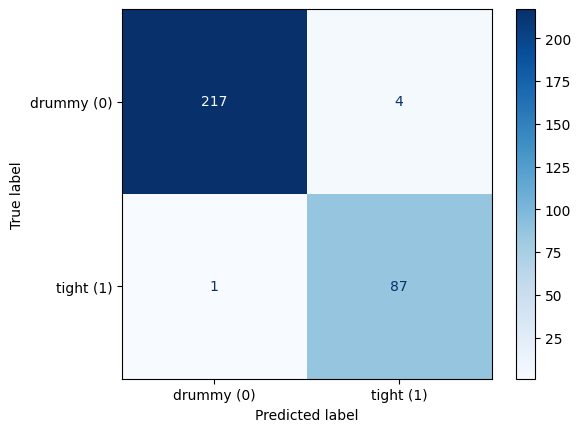


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       1.00      0.98      0.99       221
   tight (1)       0.96      0.99      0.97        88

    accuracy                           0.98       309
   macro avg       0.98      0.99      0.98       309
weighted avg       0.98      0.98      0.98       309



In [6]:
torch.manual_seed(42)
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 3000))
# val_idx = list(range(2900,3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
# val_data = torch.utils.data.Subset(data, val_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
# val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()
epochs = 20

loops.train(model=model, model_path="./model_paths/convolution.pth", train_loader=train_loader,val=False,val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model= model,model_path="./model_paths/convolution.pth", test_loader=test_loader, report=True)

# plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
# plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
# plt.title("Accuracy vs. Epochs")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.show()

In [7]:
import os, shutil

dot = shutil.which("dot") or "/opt/homebrew/bin/dot"
if not os.path.exists(dot):
    dot = "/usr/local/bin/dot"

os.environ["GRAPHVIZ_DOT"] = dot
os.environ["PATH"] += os.pathsep + os.path.dirname(dot)
from torchview import draw_graph

model.eval()
graph = draw_graph(
    model,
    input_size=(1, 1, 36000),  # batch size first
    expand_nested=True,
    device='cpu',
    save_graph=True,
    filename='../assets/conv_p1_model_arch',
)